In [1]:
# Imports for BBC data prep and later GPT-2 355M evaluation
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from datasets import DatasetDict

_ROOT = Path("..").resolve()
_SRC = _ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

from llm_doc_classification.data.bbc import (
    BBC_LABELS,
    bbc_label_maps,
    clean_bbc_splits,
    load_bbc_split,
    raw_dataset_dict_from_bbc_frames,
)
from llm_doc_classification.models.gpt2_bbc_generative import (
    BBCGenerativeDataset,
    EpochTimingAndGpuCallback,
    PadCollator,
    bbc_label_pattern,
    classification_metrics,
    generate_labels,
)
from llm_doc_classification.utils.seed import set_seed_all
from llm_doc_classification.config import (
    bbc_data_dir,
    config_path_display,
    get_seed,
    gpt2_profile,
    paths,
)
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments


In [2]:
# BBC: load splits and build HuggingFace DatasetDict (raw only; no tokenization yet)
DATA_ROOT = bbc_data_dir()
label2id, id2label = bbc_label_maps()
train_df = load_bbc_split(DATA_ROOT, "train")
val_df = load_bbc_split(DATA_ROOT, "val")
test_df = load_bbc_split(DATA_ROOT, "test")
train_df, val_df, test_df = clean_bbc_splits(
    train_df, val_df, test_df, label2id=label2id
)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

raw_datasets = raw_dataset_dict_from_bbc_frames(train_df, val_df, test_df)
print(raw_datasets)
print("Label mapping:", label2id)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Loaded train from train.csv (no train/ folder found)
Loaded val from val.csv (no val/ folder found)
Loaded test from test.csv (no test/ folder found)
Train: 1780, Val: 222, Test: 223
DatasetDict({
    train: Dataset({
        features: ['text', 'label_id', 'label', 'path'],
        num_rows: 1780
    })
    validation: Dataset({
        features: ['text', 'label_id', 'label', 'path'],
        num_rows: 222
    })
    test: Dataset({
        features: ['text', 'label_id', 'label', 'path'],
        num_rows: 223
    })
})
Label mapping: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}
Device: cuda


In [3]:
# GPT-2 Medium (~355M) — values from `configs/default.json` (`gpt2.355m`)
_P = paths()
_G = gpt2_profile("355m")
PRETRAINED = _G["pretrained"]
LOCAL_GPT2_MEDIUM_DIR = _P["models"] / _G["local_subdir"]
MODEL_OUT = _P["models"] / _G["finetune_model_subdir"]
LABELS = list(BBC_LABELS)
LABEL_PATTERN = bbc_label_pattern()
MAX_LENGTH = _G["max_length"]
MAX_NEW_TOKENS = _G["max_new_tokens"]
SEED = get_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Config:", config_path_display())
set_seed_all(SEED)


Config: D:\llm_doc_classification\configs\default.json


In [4]:
# (Prompt / generation: llm_doc_classification.models.gpt2_bbc_generative)
pass


In [5]:
# Zero-shot on test split (no training) — same pipeline as `bbc_GPT2_124M.ipynb` STAGE 1
tokenizer = AutoTokenizer.from_pretrained(PRETRAINED)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(PRETRAINED).to(device)



Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

In [6]:
zs_preds, zs_raw = generate_labels(
    model,
    tokenizer,
    test_df,
    device,
    labels=LABELS,
    label_pattern=LABEL_PATTERN,
    max_length=MAX_LENGTH,
    max_new_tokens=MAX_NEW_TOKENS,
)
zs_metrics = classification_metrics(
    test_df["label"].tolist(), zs_preds, labels=LABELS
)

print("GPT-2 Medium (355M) zero-shot results (test)")
print(f"  accuracy: {zs_metrics['accuracy']:.4f}")
print(f"  macro_f1: {zs_metrics['macro_f1']:.4f}")
print(f"  weighted_f1: {zs_metrics['weighted_f1']:.4f}")


generate:   0%|          | 0/223 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Token indices sequence length is longer than the specified maximum sequence length for this model (1669 > 1024). Running this sequence through the model will result in indexing errors


GPT-2 Medium (355M) zero-shot results (test)
  accuracy: 0.5112
  macro_f1: 0.4942
  weighted_f1: 0.5054


In [7]:
# Save pretrained GPT-2 Medium to disk so the next run can load from this folder (no Hub download).
LOCAL_GPT2_MEDIUM_DIR.mkdir(parents=True, exist_ok=True)

tokenizer.save_pretrained(str(LOCAL_GPT2_MEDIUM_DIR))
model.save_pretrained(str(LOCAL_GPT2_MEDIUM_DIR))

print(f"Saved tokenizer + weights to {LOCAL_GPT2_MEDIUM_DIR}")
print("Next session: use AutoTokenizer.from_pretrained(LOCAL_GPT2_MEDIUM_DIR) and")
print("AutoModelForCausalLM.from_pretrained(LOCAL_GPT2_MEDIUM_DIR) instead of the Hub id.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved tokenizer + weights to D:\llm_doc_classification\models\gpt2_medium
Next session: use AutoTokenizer.from_pretrained(LOCAL_GPT2_MEDIUM_DIR) and
AutoModelForCausalLM.from_pretrained(LOCAL_GPT2_MEDIUM_DIR) instead of the Hub id.


In [8]:
# Load GPT-2 Medium for downstream experiments: use saved folder if present, otherwise Hub.
load_path = (
    str(LOCAL_GPT2_MEDIUM_DIR)
    if (LOCAL_GPT2_MEDIUM_DIR / "config.json").is_file()
    else PRETRAINED
)
print("Loading tokenizer + model from:", load_path)

tokenizer = AutoTokenizer.from_pretrained(load_path)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(load_path).to(device)


Loading tokenizer + model from: D:\llm_doc_classification\models\gpt2_medium


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

In [9]:
# STAGE 2 — Fine-tuning (loss only on label tokens); same method as `bbc_GPT2_124M.ipynb`
set_seed_all(SEED)

import os
from pathlib import Path
from transformers import Trainer

base_ckpt = (
    str(LOCAL_GPT2_MEDIUM_DIR)
    if (LOCAL_GPT2_MEDIUM_DIR / "config.json").is_file()
    else PRETRAINED
)
tokenizer = AutoTokenizer.from_pretrained(base_ckpt)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(base_ckpt).to(device)

train_ds = BBCGenerativeDataset(train_df, tokenizer, MAX_LENGTH)
val_ds = BBCGenerativeDataset(val_df, tokenizer, MAX_LENGTH)

MODEL_OUT.mkdir(parents=True, exist_ok=True)
# TensorBoardCallback reads this env var (TrainingArguments.logging_dir is not used for TB in v4.45+).
TB_DIR = MODEL_OUT / "tensorboard"
TB_DIR.mkdir(parents=True, exist_ok=True)
os.environ["TENSORBOARD_LOGGING_DIR"] = str(TB_DIR)

use_fp16 = torch.cuda.is_available()
train_args = TrainingArguments(
    output_dir=str(MODEL_OUT),
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=5e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=use_fp16,
    bf16=False,
    gradient_checkpointing=True,
    save_total_limit=2,
    seed=SEED,
    data_seed=SEED,
    dataloader_num_workers=0,
    report_to=["tensorboard"],
    logging_first_step=True,
    eval_on_start=True,
    disable_tqdm=False,
)
print("TensorBoard event files (TENSORBOARD_LOGGING_DIR):", TB_DIR)
print("View live: tensorboard --logdir", str(TB_DIR))

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=PadCollator(tokenizer),
    callbacks=[EpochTimingAndGpuCallback()],
)



Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1067 > 1024). Running this sequence through the model will result in indexing errors
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TensorBoard event files (TENSORBOARD_LOGGING_DIR): D:\llm_doc_classification\models\gpt2_medium_bbc\tensorboard
View live: tensorboard --logdir D:\llm_doc_classification\models\gpt2_medium_bbc\tensorboard


In [ ]:
print("Starting GPT-2 Medium fine-tuning (label-token loss only)...")
trainer.train()


Starting GPT-2 Medium fine-tuning (label-token loss only)...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
0,No log,9.243389
1,0.111586,0.239435
2,0.054878,0.071834
3,0.000682,0.063625



Epoch 1 started...
Epoch 1 training time: 3325.24s
GPU usage (GB) - allocated: 3.98, reserved: 7.15, peak allocated: 6.62


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


Epoch 3 started...
Epoch 3 training time: 3579.81s
GPU usage (GB) - allocated: 3.98, reserved: 7.15, peak allocated: 6.62


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('D:\\llm_doc_classification\\models\\gpt2_medium_bbc\\tokenizer_config.json',
 'D:\\llm_doc_classification\\models\\gpt2_medium_bbc\\tokenizer.json')

In [11]:
# Save fine-tuned weights + tokenizer to MODEL_OUT (run after training cell).
trainer.save_model(str(MODEL_OUT))
tokenizer.save_pretrained(str(MODEL_OUT))
print(f"Fine-tuned model and tokenizer saved to: {MODEL_OUT}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model and tokenizer saved to: D:\llm_doc_classification\models\gpt2_medium_bbc


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generate:   0%|          | 0/223 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1669 > 1024). Running this sequence through the model will result in indexing errors


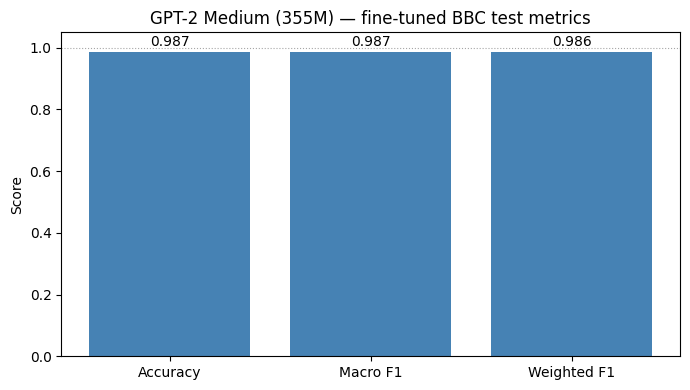

In [13]:
# Fine-tuned checkpoint: test-set classification metrics (from saved MODEL_OUT).
import matplotlib.pyplot as plt

if not (MODEL_OUT / "config.json").is_file():
    raise FileNotFoundError(
        f"No fine-tuned checkpoint at {MODEL_OUT}. Run the training and save cells first."
    )

ft_model = AutoModelForCausalLM.from_pretrained(str(MODEL_OUT)).to(device)
ft_tok = AutoTokenizer.from_pretrained(str(MODEL_OUT))
ft_tok.pad_token = ft_tok.eos_token
ft_preds, _ = generate_labels(
    ft_model,
    ft_tok,
    test_df,
    device,
    labels=LABELS,
    label_pattern=LABEL_PATTERN,
    max_length=MAX_LENGTH,
    max_new_tokens=MAX_NEW_TOKENS,
)
ft_metrics = classification_metrics(
    test_df["label"].tolist(), ft_preds, labels=LABELS
)
del ft_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

metric_keys = ["accuracy", "macro_f1", "weighted_f1"]
vals = [float(ft_metrics[k]) for k in metric_keys]
x_labels = ["Accuracy", "Macro F1", "Weighted F1"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x_labels, vals, color="steelblue")
ax.set_ylabel("Score")
ax.set_title("GPT-2 Medium (355M) — fine-tuned BBC test metrics")
ax.set_ylim(0, 1.05)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)
fig.tight_layout()
plt.show()